In [1]:
import warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pint.errors import UnitStrippedWarning

import prism
from imagematerials.read_mym import read_mym_df

from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    GenericMaterials,
    GenericStocks,
    MaterialIntensities,
    SharesInflowStocks
)
from imagematerials.vehicles.battery import ElectricVehicleBatteries, BatteryMaterials, EvBatteryLinkModule, ElectricVehicleBatteriesWeights
from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.electricity.preprocessing import get_preprocessing_data_evbattery, get_preprocessing_data_evbattery_old

from imagematerials.electricity.constants import STANDARD_SCEN_EXTERNAL_DATA

path_current = Path().resolve()
path_base = path_current.parent #.parent # base path of the project -> image-materials
path_data = Path(path_base, "data", "raw")

# Old

In [90]:
scenario_list = {"SSP2_M_CP":("SSP2_M_CP", None),
                # "SSP2_narrow":("SSP2_narrow", "narrow"),
                 }

# scenario_base_path = Path(path_base) / 'circular_economy_scenarios'

time_start = 1971
time_end = 2100
complete_timeline = prism.Timeline(time_start, time_end, 1)
simulation_timeline = prism.Timeline(time_start, time_end, 1)

all_output_old = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path(path_data, "image", climate_scen)
    circular_economy_scenario_dir = None #Path(path_base, "circular_economy_scenarios", circular_scen)

    vhc_sector = get_preprocessing_data("vehicles", path_data, 
                                    climate_policy_scenario_dir = climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None)
    

    factory = ModelFactory(
        [vhc_sector], complete_timeline
        ).add(GenericStocks, "vehicles"
        ).add(BatteryMaterials, "vehicles"
        ).add(GenericMaterials, "vehicles"
        )
    model_old = factory.finish()

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UnitStrippedWarning)
        model_old.simulate(simulation_timeline)
    all_output_old[scen_id] = model_old
    print(f"Finished {scen_id}")

# list(model.vehicles)

Finished SSP2_M_CP


# New

In [ ]:
# Only batteries #

scenario_list = {"SSP2_M_CP":("SSP2_M_CP", None),
                # "SSP2_narrow":("SSP2_narrow", "narrow"),
                 }

# scenario_base_path = Path(path_base) / 'circular_economy_scenarios'

time_start = 1971
time_end = 2100
complete_timeline = prism.Timeline(time_start, time_end, 1)
simulation_timeline = prism.Timeline(time_start, time_end, 1)

all_output_2 = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path(path_data, "image", climate_scen)
    # climate_policy_scenario_dir = Path(path_base, "IMAGE_CircoMod", climate_scen)
    circular_economy_scenario_dir = None #Path(path_base, "circular_economy_scenarios", circular_scen)
    scenario = path_base /"electricity"/ STANDARD_SCEN_EXTERNAL_DATA

    vhc_sector = get_preprocessing_data("vehicles", path_data, 
                                    climate_policy_scenario_dir = climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None)
    ev_battery_sector = get_preprocessing_data("ev_battery", path_data,
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dir, cache = False, standard_scenario = scenario)     
    # elc_sector = get_preprocessing_data("electricity", path_data,
    #                                     climate_policy_scenario_dir, 
    #                                     circular_economy_scenario_dir, cache = False, standard_scenario = scenario) 
    # elc_sector is a list of preprocessing data for each electricity subsector
    

    factory = ModelFactory(
        [vhc_sector, ev_battery_sector], complete_timeline
        ).add(GenericStocks, ["vehicles"]
        ).add(ElectricVehicleBatteries, ["ev_battery"], input_sources={
        "stock_by_cohort": "vehicles",
        "inflow": "vehicles",
        "outflow_by_cohort": "vehicles"}
        ).add(GenericMaterials, "vehicles"
        )
    model_2 = factory.finish()

    model_2.simulate(simulation_timeline)
    all_output_2[scen_id] = model_2
    print(f"Finished {scen_id}")

list(model_2.ev_battery)

In [2]:
# All 3 sectors #

scenario_list = {
                "SSP2_VLHO":("SSP2_VLHO", None),
                "SSP2_M_CP":("SSP2_M_CP", None),
                 }

# scenario_base_path = Path(path_base) / 'circular_economy_scenarios'

time_start = 1971
time_end = 2100
complete_timeline = prism.Timeline(time_start, time_end, 1)
simulation_timeline = prism.Timeline(time_start, time_end, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path(path_data, "image", climate_scen)
    # climate_policy_scenario_dir = Path(path_base, "IMAGE_CircoMod", climate_scen)
    circular_economy_scenario_dir = None #Path(path_base, "circular_economy_scenarios", circular_scen)
    scenario = path_base /"electricity"/ STANDARD_SCEN_EXTERNAL_DATA

    vhc_sector = get_preprocessing_data("vehicles", path_data, 
                                    climate_policy_scenario_dir = Path(climate_policy_scenario_dir), 
                                    circular_economy_scenario_dirs = None)
    ev_battery_sector = get_preprocessing_data("ev_battery", path_data,
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dir, cache = False, standard_scenario = scenario)     
    elc_sector = get_preprocessing_data("electricity", path_data,
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dir, cache = False, standard_scenario = scenario) 
    # elc_sector is a list of preprocessing data for each electricity subsector
    

    factory = ModelFactory(
        [vhc_sector, ev_battery_sector, *elc_sector], complete_timeline
        ).add(GenericStocks, ["vehicles",
                              "elc_gen",
                              "elc_grid_lines",
                              "elc_grid_add",
                              "elc_stor_phs"]
        ).add(GenericMaterials, ["vehicles"]
        ).add(ElectricVehicleBatteriesWeights, ["ev_battery"], input_sources={
        "stock_by_cohort": "vehicles",
        "inflow": "vehicles",
        "outflow_by_cohort": "vehicles"}
        ).add(EvBatteryLinkModule, ["elc_stor_other"], input_sources={
        "stock_battery_kWh_v2g": "ev_battery"}
        ).add(SharesInflowStocks, ["elc_stor_other"],
        ).add(MaterialIntensities, ["elc_gen",
                                    "elc_grid_lines",
                                    "elc_grid_add",
                                    "elc_stor_phs",
                                    "elc_stor_other"
                                    ]
        )
    model = factory.finish()

    model.simulate(simulation_timeline)
    all_output[scen_id] = model
    print(f"Finished {scen_id}")
    del factory

list(model.ev_battery)

Finished SSP2_VLHO
Finished SSP2_M_CP


['shares',
 'weights',
 'material_fractions',
 'energy_density',
 'vhc_fraction_v2g',
 'capacity_fraction_v2g',
 'knowledge_graph_elc',
 'knowledge_graph_vhc',
 'stock_battery_kWh_v2g',
 'inflow_battery_kWh',
 'stock_battery_kWh',
 'outflow_battery_kWh',
 'inflow_battery_kg',
 'stock_battery_kg',
 'outflow_battery_kg',
 'inflow_battery_materials',
 'stock_battery_materials',
 'outflow_battery_materials']

# Calculations

In [61]:
model = all_output["SSP2_M_CP"]

# change in vehicles inflow
m1 = model.vehicles["inflow"].to_array().sum(["Region"])
m1_ev = m1.sel(Type=m1.Type.str.contains("BEV|PHEV")).sum("Type")
r_ev = m1_ev.sel(time=2050)/m1_ev.sel(time=2030)

# change in battery inflow
m2 = model.ev_battery["inflow_battery_kWh"].to_array().sum(["Region", "BatteryType", "Type"])
r_bat = m2.sel(time=2050)/m2.sel(time=2030)

# change in energy density
m3 = model.ev_battery["energy_density"]
m3_sum = m3.sum("BatteryType")
r_energy_density = m3_sum.sel(Cohort=2050)/m3_sum.sel(Cohort=2030)


In [69]:
print("Increase from 2030 to 2050:")
print("EV vehicles inflow", round(prism.M_(r_ev).values.item(), 1))
print("Battery inflow", round(prism.M_(r_bat).values.item(), 1))
print("energy_density", prism.M_(r_energy_density).values)
print("energy density NMC in 2050", prism.M_(m3.sel(BatteryType="NMC").sel(Cohort=2050)).values)
print("energy density Lithium Ceramic in 2050", prism.M_(m3.sel(BatteryType="Lithium Ceramic").sel(Cohort=2050)).values)
print("unit energy density", prism.U_(m3))

Increase from 2030 to 2050:
EV vehicles inflow 2.0
Battery inflow 4.2
energy_density 1.0
energy density NMC in 2050 3.53
energy density Lithium Ceramic in 2050 1.35
unit energy density kilogram / kilowatt_hour


# Plots

### external data

In [87]:
# read the external files
df_ev_battery_i =       pd.read_csv(Path(path_data,"electricity","lit_ev_battery_inflow.csv"), index_col = [0])
df_ev_battery_s =       pd.read_csv(Path(path_data,"electricity","lit_ev_battery_stock.csv"), index_col = [0])
df_ev_vehicles_i =      pd.read_csv(Path(path_data,"electricity","lit_ev_vehicles_inflow.csv"), index_col = [0])
df_ev_vehicles_s =      pd.read_csv(Path(path_data,"electricity","lit_ev_vehicles_stock.csv"), index_col = [0])
df_storage_power_i =    pd.read_csv(Path(path_data,"electricity","lit_grid_storage_inflow_power_GW.csv"), index_col = [0])
df_storage_power_s =    pd.read_csv(Path(path_data,"electricity","lit_grid_storage_stock_power_GW.csv"), index_col = [0])
df_storage_energy_i =   pd.read_csv(Path(path_data,"electricity","lit_grid_storage_inflow_energy_GWh.csv"), index_col = [0])
df_storage_energy_s =   pd.read_csv(Path(path_data,"electricity","lit_grid_storage_stock_energy_GWh.csv"), index_col = [0])
# Assumptions to convert GW to GWh
duration_battery = 4 # assume 4 h duration
duration_phd = 8 # 8 h

# TIMER
path_image = Path(path_data, "image", "SSP2_M_CP", "EnergyServices")
df_energy_timer_data = read_mym_df(Path(path_data, "image", "SSP2_M_CP", "EnergyServices", "StorResTot.out"))
df_energy_timer_data_vlho = read_mym_df(Path(path_data, "image", "SSP2_VLHO", "EnergyServices", "StorResTot.out"))
df_power_timer_data = read_mym_df(Path(path_data, "image", "SSP2_M_CP", "EnergyServices", "StorCapTot.out"))
df_power_timer_data_vlho = read_mym_df(Path(path_data, "image", "SSP2_VLHO", "EnergyServices", "StorCapTot.out"))
df_energy_timer_data_seb = read_mym_df(Path(path_data, "image", "SSP2_BL", "StorResTot.out"))
df_power_timer_data_seb = read_mym_df(Path(path_data, "image", "SSP2_BL",  "StorCapTot.out"))

df_energy_timer = df_energy_timer_data.rename(columns={28: "global"})/1000 # MWh->GWh
df_energy_timer_vlho = df_energy_timer_data_vlho.rename(columns={28: "global"})/1000 # MWh->GWh
df_energy_timer_seb = df_energy_timer_data_seb.rename(columns={28: "global"})/1000 # MWh->GWh
df_power_timer = df_power_timer_data.rename(columns={28: "global"})/1000 # MW->GW
df_power_timer_seb = df_power_timer_data_seb.rename(columns={28: "global"})/1000 # MW->GW
df_power_timer_vlho = df_power_timer_data_vlho.rename(columns={28: "global"})/1000 # MW->GW

In [80]:
df_power_timer

,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,global
time,,,,,,,,,,,,,,,,,,,,,
1971,0.566552,2.974242,0.036593,0.018784,0.056493,0.070062,0.051092,0.035703,0.010615,0.190232,...,0.043731,0.189454,0.028221,0.002400,0.681613,0.110327,0.012234,0.022081,0.0,11.91420
1972,0.646207,2.975325,0.041501,0.020934,0.061750,0.074460,0.051769,0.038575,0.011429,0.206361,...,0.047065,0.207892,0.032031,0.002773,0.728334,0.108924,0.012266,0.031603,0.0,12.48037
1973,0.716047,3.248410,0.045129,0.023289,0.071535,0.083281,0.053047,0.042952,0.011596,0.219355,...,0.053265,0.227295,0.037821,0.003406,0.788479,0.124121,0.014252,0.040174,0.0,13.45664
1974,0.740737,3.273476,0.057156,0.024332,0.079688,0.091067,0.056724,0.043064,0.011216,0.234715,...,0.058564,0.235127,0.040246,0.004519,0.778554,0.133238,0.016035,0.050632,0.0,13.91392
1975,0.721279,3.369763,0.060580,0.024186,0.085837,0.095395,0.064478,0.048296,0.011678,0.252280,...,0.065505,0.278350,0.041937,0.005131,0.796160,0.138231,0.017998,0.053294,0.0,13.98489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096,64.083460,582.287100,254.229300,34.886080,412.149100,255.445400,535.955800,800.998100,495.141000,122.569000,...,14.843450,1090.652000,130.679200,61.388250,15.808100,118.278100,717.950200,307.937800,0.0,7610.47400
2097,62.107890,572.233300,262.465700,35.262110,431.388800,257.374300,553.107900,825.539000,508.231700,120.463400,...,14.939230,1071.654000,129.034800,62.504940,17.186440,119.395500,690.003400,318.100600,0.0,7656.65200
2098,63.651750,564.685700,271.244500,36.244780,444.023600,259.241800,564.923900,850.394000,525.330600,121.364200,...,15.143860,1051.078000,127.083000,63.887660,17.953630,120.469300,664.746900,328.347000,0.0,7700.91600


### Battery

#### i: battery (GWh)

In [ ]:
# INFLOW EV BATTERIES GWh #

df = df_ev_battery_i.loc[(df_ev_battery_i["Technology"] == "all_modes")&(df_ev_battery_i["unit"] == "GWh")]

# Plot ev_battery: materials over time
var = "inflow_battery_kWh"
model = all_output["SSP2_M_CP"]
m2 = model.ev_battery[var].to_array().sum(["BatteryType", "Region", "Type"]).sel(time=slice(1972,None))/1000000
model = all_output["SSP2_VLHO"]
m1 = model.ev_battery[var].to_array().sum(["BatteryType", "Region", "Type"]).sel(time=slice(1972,None))/1000000

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(m1.time, m1, label="IMAGE-Materials - SSP2_VLHO", linewidth=1, c="black", linestyle = "--")
plt.plot(m2.time, m2, label="IMAGE-Materials - SSP2_M_CP", linewidth=1, c="black")
for (source, scenario), g in df.groupby(["source", "scenario"]):
    plt.scatter(g.index, g["value"], label=f"{source} – {scenario}", linewidth=1)

plt.xlim(2010,2060)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.ylabel(f"Inflow EV batteries (GWh)", fontsize=14)
plt.legend()
plt.title(f"Inflow EV batteries", fontsize=14)

#### s: battery (kg)

In [ ]:
# STOCK EV BATTERIES kg #

df = df_ev_battery_s.loc[(df_ev_battery_s["Technology"] == "all_modes")&(df_ev_battery_s["unit"] == "kg")]

# Plot ev_battery: materials over time
model = all_output["SSP2_M_CP"]
m4 = model.vehicles["stock_by_cohort_materials"].sum(["material", "Region", "Type"]).sel(Time=slice(1972,None))
m3 = model.elc_stor_other["stock_by_cohort_materials"].sum(["material", "Region", "Type"]).sel(Time=slice(1972,None))
var = "stock_battery_kg"
m2 = model.ev_battery[var].to_array().sum(["BatteryType", "Region", "Type"]).sel(time=slice(1972,None)) #, "Cohort"
m21 = model.ev_battery["stock_battery_materials"].to_array().sum(["BatteryType", "Region", "Type", "material"]).sel(time=slice(1972,None))
# model = all_output["SSP2_VLHO"]
# m1 = model.ev_battery[var].to_array().sum(["BatteryType", "Region", "Type"]).sel(time=slice(1972,None)) #, "Cohort"

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(m4.Time, m4, label="IMAGE-Materials - vehicles", linewidth=1, c="purple", linestyle = ":")
plt.plot(m3.Time, m3, label="IMAGE-Materials - dedicated storage", linewidth=1, c="black", linestyle = ":")
# plt.plot(m1.time, m1, label="IMAGE-Materials - SSP2_VLHO", linewidth=1, c="black", linestyle = "--")
plt.plot(m2.time, m2, label="IMAGE-Materials - EV bat.", linewidth=1, c="black") # - SSP2_M_CP
plt.plot(m21.time, m21, label="IMAGE-Materials - EV bat. - sum materials", linewidth=1, c="orange")
for (source, scenario), g in df.groupby(["source", "scenario"]):
    plt.scatter(g.index, g["value"], label=f"{source} – {scenario} - EV bat.", linewidth=1)

# plt.xlim(2010,2060)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.ylabel(f"Stock EV batteries (kg)", fontsize=14)
plt.legend()
plt.title(f"Stock EV batteries (SSP2_M_CP)", fontsize=14)

#### s: battery per battery type (normalized stacked plot)

c:\Users\Judit\anaconda3\envs\image-materials\lib\site-packages\xarray\core\variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


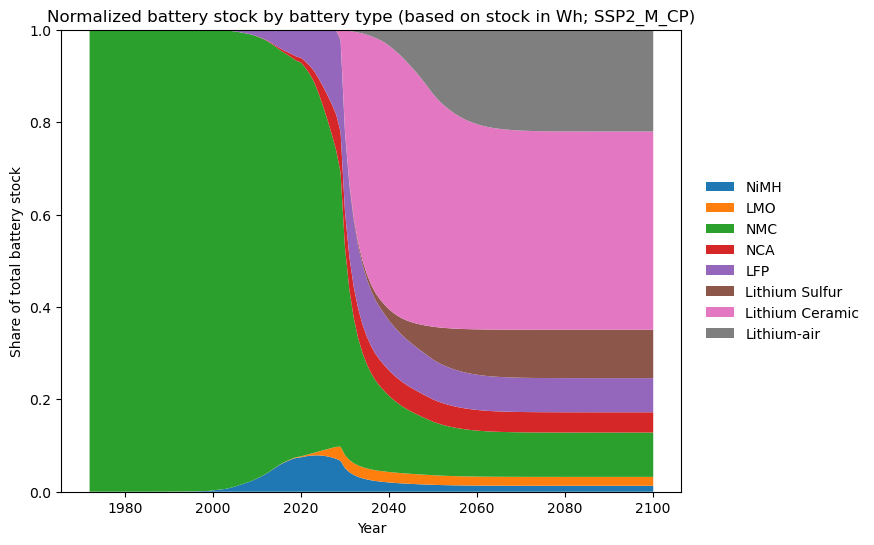

In [59]:
# Battery stocks per battery type (normalized stacked plot)

var = "stock_battery_kWh"
m2 = (
    model.ev_battery[var]
    .to_array()
    .sum(["Region", "Type", "Cohort"])
    .sel(time=slice(1972, None))
)

# normalize to shares
m2_share = m2 / m2.sum(dim="BatteryType")

fig, ax = plt.subplots(figsize=(8, 6))

battery_types = m2_share.BatteryType.values
ax.stackplot(
    m2_share.time,
    [m2_share.sel(BatteryType=bt) for bt in battery_types],
    labels=battery_types
)

ax.set_xlabel("Year")
ax.set_ylabel("Share of total battery stock")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_title(f"Normalized battery stock by battery type (based on stock in Wh; SSP2_M_CP)")

plt.show()


#### s: battery per battery type

In [ ]:
# Battery stocks per battery type #

var = "stock_battery_kWh"
m2 = model.ev_battery[var].to_array().sum(["Region", "Type", "Cohort"]).sel(time=slice(1972,None))

fig,ax = plt.subplots(figsize=(8,6))
for i, mat in enumerate(model.ev_battery["stock_battery_kWh"].to_array().BatteryType.values):
    plt.plot(m2.time, m2.sel(BatteryType=mat), label=str(mat), linestyle="-", linewidth=2) #"m2 - " + 
plt.xlabel("Year")
plt.ylabel(f"{var} in EV batteries (kWh)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.title(f"{var} in EV batteries (SSP2_M_CP)")

#### i: battery materials

Text(0.5, 1.0, 'inflow_battery_materials in EV batteries')

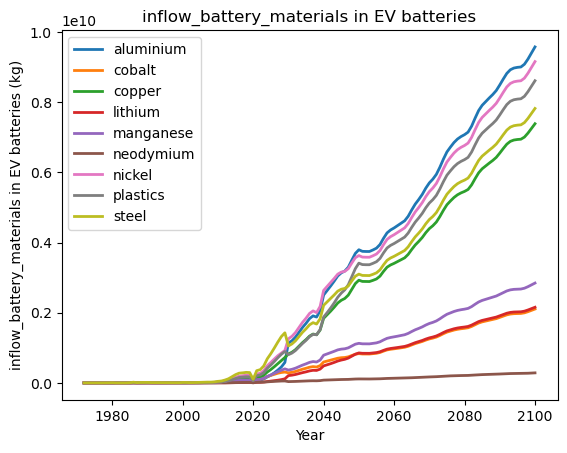

In [99]:
# Plot ev_battery: materials over time
var = "inflow_battery_materials"

model = all_output["SSP2_M_CP"]
m = model.ev_battery[var].to_array().sum(["BatteryType", "Region", "Type"]).sel(time=slice(1972,None))

non_zero_materials = model.ev_battery["material_fractions"].material.where(
    (model.ev_battery["material_fractions"] != 0).any(dim=["Cohort", "BatteryType"]),
    drop=True).values

for mat in list(non_zero_materials): #
    plt.plot(m.time, m.sel(material=mat), label=str(mat), linewidth=2)
    
plt.xlabel("Year")
plt.ylabel(f"{var} in EV batteries (kg)")
plt.legend()
plt.title(f"{var} in EV batteries")

#### energy density

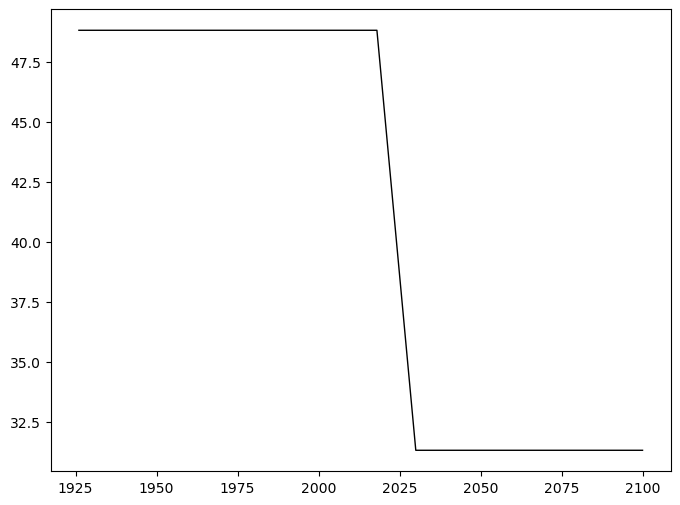

In [53]:
model = all_output["SSP2_M_CP"]
m = model.ev_battery["energy_density"].sum(["BatteryType"])
m
fig, ax = plt.subplots(figsize=(8,6))
plt.plot(m.Cohort, m, label="IMAGE-Materials - SSP2_M_CP", linewidth=1, c="black")

### Storage

#### s: Comp.: TIMER storage (GW)

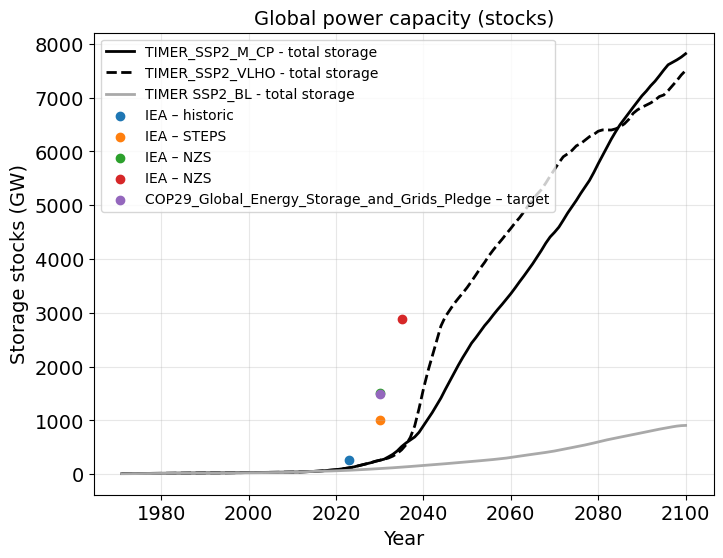

In [86]:
df = df_storage_power_s.copy()
df1 = df[(df["technology"] == "total")]
df1.reset_index(drop=False,inplace=True)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(df_power_timer.index, df_power_timer["global"], linewidth=2, c="black",
        label="TIMER_SSP2_M_CP - total storage")
ax.plot(df_power_timer_vlho.index, df_power_timer_vlho["global"], linewidth=2, c="black", linestyle="--",
        label="TIMER_SSP2_VLHO - total storage")
ax.plot(df_power_timer_seb.index, df_power_timer_seb["global"], linewidth=2, c="darkgray",
        label="TIMER SSP2_BL - total storage")
for row in range(len(df1)):
    src = df1["source"].iloc[row]
    scen = df1["scenario"].iloc[row]
    plt.scatter(df1["time"].iloc[row], df1["value"].iloc[row], label=f"{src} – {scen}", linewidth=1)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Storage stocks (GW)", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Global power capacity (stocks)", fontsize=14)
plt.show()

#### s: Comp.: TIMER storage (GWh)

Text(0.5, 1.0, 'Global energy storage (stocks)')

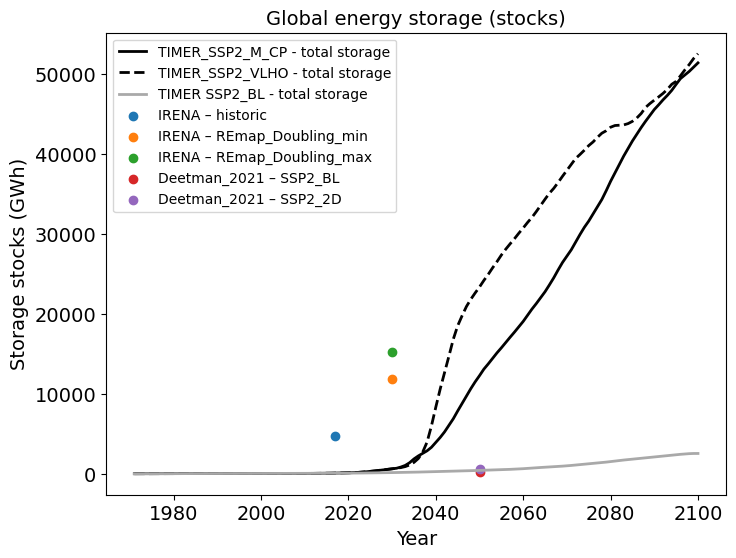

In [88]:
# TIMER GWh storage comparison
# comparison of SSP2_BL which Sebastiaan used to newer SSP2_M_CP runs + external data #

df = df_storage_energy_s.copy()
df1 = df[(df["source"] == "IRENA") & (df["category"] == "total")]
df1.reset_index(drop=False,inplace=True)

df2 = df[(df["category"] == "grid_scale_storage") & (df["technology"] == "battery")]
df2.reset_index(drop=False,inplace=True)

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(df_energy_timer.index, df_energy_timer["global"], linewidth=2, c="black",
        label="TIMER_SSP2_M_CP - total storage")
ax.plot(df_energy_timer_vlho.index, df_energy_timer_vlho["global"], linewidth=2, c="black", linestyle="--",
        label="TIMER_SSP2_VLHO - total storage")
ax.plot(df_energy_timer_seb.index, df_energy_timer_seb["global"], linewidth=2, c="darkgray",
        label="TIMER SSP2_BL - total storage")
for row in range(len(df1)):
    src = df1["source"].iloc[row]
    scen = df1["scenario"].iloc[row]
    plt.scatter(df1["time"].iloc[row], df1["value"].iloc[row], label=f"{src} – {scen}", linewidth=1)
for row in range(len(df2)):
    src = df2["source"].iloc[row]
    scen = df2["scenario"].iloc[row]
    plt.scatter(df2["time"].iloc[row], df2["value"].iloc[row], label=f"{src} – {scen}", linewidth=1)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Storage stocks (GWh)", fontsize=14)
ax.tick_params(axis='both', labelsize=14)


lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels)

ax.set_title("Global energy storage (stocks)", fontsize=14)

#### s: Storage stock 3-tier

Text(0.5, 1.0, 'Stocks of storage technologies')

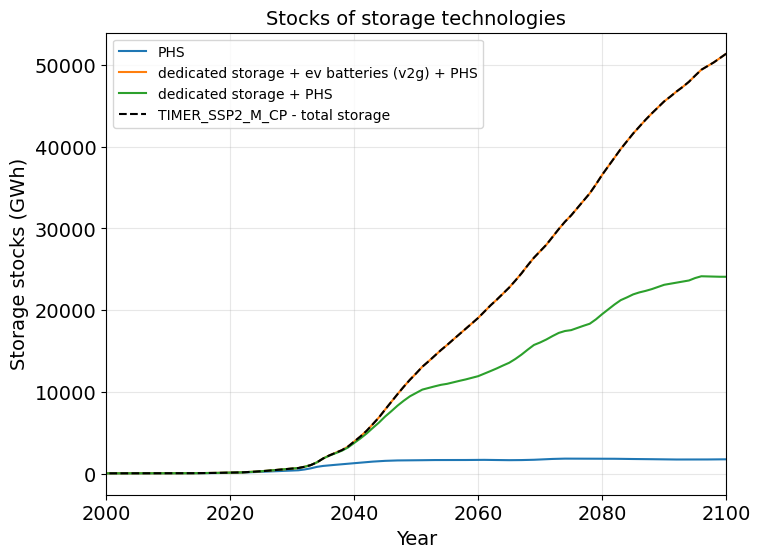

In [38]:
# Plot storage (3-tier) #

# PLOT
fig, ax = plt.subplots(figsize=(8,6))
model = all_output["SSP2_M_CP"]
phs = model.elc_stor_phs["stocks"].sum(["Type", "Region"]).pint.to("GWh")
s_0 = model.elc_stor_other["stocks_non_phs"].sum(["SuperType", "Region"]).pint.to("GWh")
s2 = s_0 + phs
s = model.elc_stor_other["stocks"].sum(["SuperType", "Region"]).pint.to("GWh")
s1 = s+phs


plt.plot(phs.Time, phs, label="PHS")
plt.plot(s2.Time, s2, label="dedicated storage + ev batteries (v2g) + PHS")
plt.plot(s1.Time, s1, label="dedicated storage + PHS")
# plt.plot(test.Time, test, label="test", linestyle=":")
plt.plot(df_energy_timer.index, df_energy_timer["global"], label="TIMER_SSP2_M_CP - total storage", c="black", linestyle="--")
# plt.plot(df_energy_timer_seb.index, df_energy_timer_seb["global"], label="TIMER SSP2_BL - total storage", c="black", linestyle="--")


ax.set_xlim(2000,2100)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.ylabel(f"Storage stocks (GWh)", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.title(f"Stocks of storage technologies", fontsize=14)

In [ ]:
df = df_storage_energy_s.loc[df_storage_energy_s.index<2100]
df

#### s: PHS

In [ ]:
# Plot PHS storage #

df = df_storage_energy_s.loc[(df_storage_energy_s.index<2100) & (df_storage_energy_s["technology"] == "PHS")]

fig, ax = plt.subplots(figsize=(8,6))
# s_0 = model.elc_stor_other["stocks_0"].sum(["SuperType", "Region"]).pint.to("GWh")
# s = model.elc_stor_other["stocks"].sum(["SuperType", "Region"]).pint.to("GWh")
phs = model.elc_stor_phs["stocks"].sum(["Type", "Region"]).pint.to("GWh")

plt.plot(phs.Time, phs, label="IMAGE-Materials - SSP2_M_CP", c="black")
for (source, scenario), g in df.groupby(["source", "scenario"]):
    plt.scatter(g.index, g["value"], label=f"{source} – {scenario}", linewidth=1)

ax.set_xlim(2000,2100)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.ylabel(f"PHS stocks (GWh)", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.title(f"Stocks of Pumped Hydropower Storage", fontsize=14)

In [ ]:
model.ev_battery["stock_battery_kWh"].to_array()#.BatteryType.values

#### s: battery vs. vehicles materials

In [ ]:
# Compare materials stock: battery vs. vehicles #
import numpy as np
var = "stock_battery_materials"
m1 = model.vehicles["stock_by_cohort_materials"].sum(["Region", "Type"]).sel(Time=slice(1972,None))
m2 = model.ev_battery[var].to_array().sum(["BatteryType", "Region", "Type"]).sel(time=slice(1972,None))

common_materials = m1.material.values[np.isin(m1.material.values, m2.material.values)]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(figsize=(8,6))
for i, mat in enumerate(common_materials):
    color = colors[i % len(colors)]
    plt.plot(m1.Time, m1.sel(material=mat), label="m1 - " + str(mat), color=color)
    plt.plot(m2.time, m2.sel(material=mat), label="m2 - " + str(mat),color=color, linestyle=":", linewidth=2)
plt.xlabel("Year")
plt.ylabel(f"{var} in EV batteries (kg)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.title(f"{var} in EV batteries")

In [ ]:
model = all_output["SSP2_M_CP"]
m1 = model.vehicles["stock_by_cohort"].sum(["Cohort", "Region"])
m1_bev = m1.sel(Type=m1.Type.str.contains("BEV")) #|PHEV
m1_phev = m1.sel(Type=m1.Type.str.contains("PHEV"))
cars_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Cars"))
cars_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Cars"))
buses_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Buses")).sum("Type")
buses_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Buses")).sum("Type")
trucks_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Trucks")).sum("Type")
trucks_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Trucks")).sum("Type")

<xarray.DataArray (Time: 294, Type: 2)> Size: 5kB
<Quantity([[       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
 [       0.                0.        ]
...
 [ 5122240.80952793  6602457.23002116]
 [ 5040909.04128688  6484729.81355085]
 [ 4980408.44650938  6384010.0124715 ]
 [ 4937146.85047596  6299699.01149615]
 [ 4902858.47720882  6226330.61073363]
 [ 4868236.90854245  6152970.49651007]
 [ 4825989.42948851  6073706.48054188]
 [ 4767037.92509216  5987494.40009073]
 [ 4702159.91843554  5903096.28465507]
 [ 4630305.34592486  5815156.16416916]
 [ 4547931.89019253  5722184.96650607]
 [ 4459250.07321979  5628045.55538399]
 [ 4369170.69852775  5536651.86079297]
 [ 4279729.18611668  5447962.4713067 ]
 [ 4192665.69247981  5362175.72932618]
 [ 4105768.24963808  5275469.30055961]
 [ 4018894.86350301  5192768.35736216]
 [ 3938404.52587682  5112464.91148359]
 [ 3860984.78600736  5032440.819836  ]
 [ 3786270.47706354  4951348.59208149]], 'count')>
Coordinates:
  * Time     (Time) int64 2kB 1807 1808 1809 1810 1811 ... 2097 2098 2099 2100
  * Type     (Type) <U35 280B 'Heavy Freight Trucks - PHEV' 'Medium Freight T...

In [20]:
cars_bev

Magnitude,[70172.47887557207 69253.12350907375 76474.30310778716 79291.06614708377 83185.03406446261 85010.79855036893 83435.61058865838 85206.22977768224 83307.75907533156 77768.57214068351 72172.83840581708 66657.94862107106 63685.16818226623 60549.15891812222 56609.197011151075 213704.466935504 366803.54147994134 587416.5450560973 943917.2225640551 1371043.6651075552 1635086.3484912084 2341558.0260169324 6189357.891916899 13619664.904132612 25751935.504405633 41820493.400651716 62289834.8087382 86505866.60194515 114394162.80582121 145670335.94927555 180709291.75041366 216835640.37284657 254357397.29777315 293471777.49294394 335946577.441607 380962745.0783626 429249012.195123 479670923.4525611 527147321.9377421 575983522.957406 625201132.3943461 673021950.7547271 719246874.7361273 763920549.9367973 807122341.3374821 848578717.2948707 886985508.2205803 923252552.0661263 957543581.5533576 989805418.8291776 1020435871.0474184 1048739860.0659467 1076166621.7077801 1102799558.738806 1128169503.703242 1152334383.2258167 1175045145.2180874 1197339803.5508657 1219805759.3213902 1242503356.990252 1265851377.8413699]
Units,count


#### s: V2G

Text(0.5, 1.0, 'stock of EV batteries per mode')

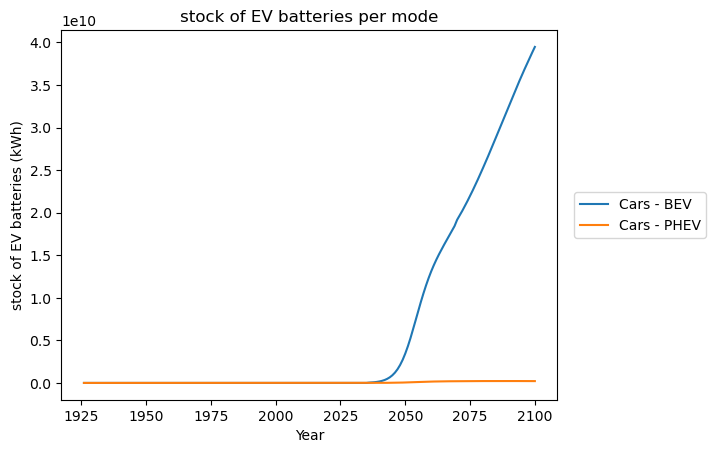

In [52]:
# Plot ev_battery: input parameter over time
var = 'stock_battery_kWh_v2g'
m = model.ev_battery[var].sum(["BatteryType","Region"])
# t="test"
for t in m.Type.values: #["Cars - PHEV"]
    plt.plot(m.Time, m.sel(Type=t), label=str(t)) #
plt.xlabel("Year")
plt.ylabel("stock of EV batteries (kWh)")
plt.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.title("stock of EV batteries per mode")

### vehicles

#### s: vehicles

Text(0.5, 1.0, 'Stocks of EV Vehicles')

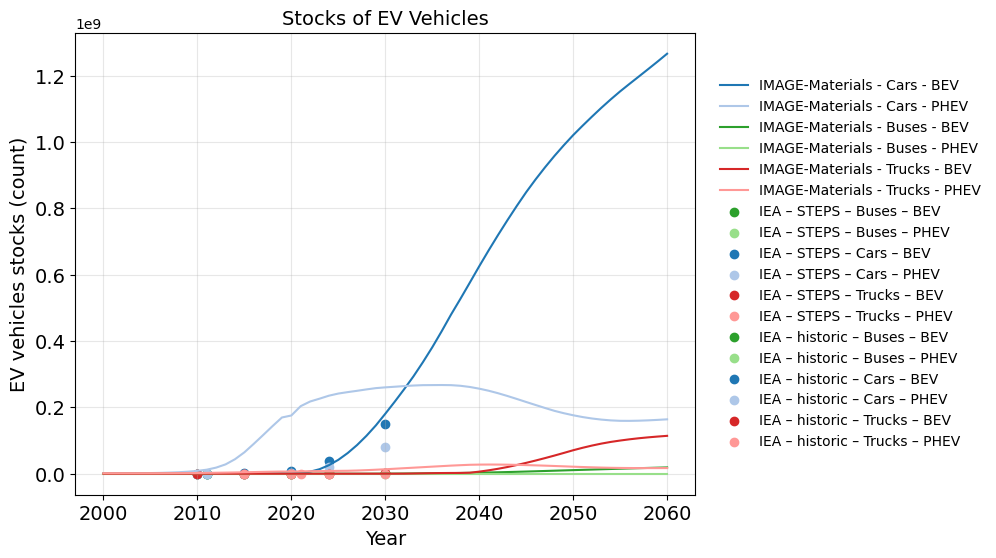

In [28]:
# Plot vehicles stock #

df = df_ev_vehicles_s.copy()

model = all_output["SSP2_M_CP"]
m1 = model.vehicles["stock_by_cohort"].sum(["Cohort", "Region"]).sel(Time=slice(2000,2060)) #2005,2031
m1_bev = m1.sel(Type=m1.Type.str.contains("BEV")) #|PHEV
m1_phev = m1.sel(Type=m1.Type.str.contains("PHEV"))
cars_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Cars")).sum("Type")
cars_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Cars")).sum("Type")
buses_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Buses")).sum("Type")
buses_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Buses")).sum("Type")
trucks_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Trucks")).sum("Type")
trucks_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Trucks")).sum("Type")

color_dict = {
    ("Cars", "BEV"): "#1f77b4",
    ("Cars", "PHEV"): "#aec7e8",
    ("Buses", "BEV"): "#2ca02c",
    ("Buses", "PHEV"): "#98df8a",
    ("Trucks", "BEV"): "#d62728",
    ("Trucks", "PHEV"): "#ff9896",
}


fig, ax = plt.subplots(figsize=(8,6))

plt.plot(cars_bev.Time, cars_bev, label="IMAGE-Materials - Cars - BEV", color=color_dict[("Cars", "BEV")])
plt.plot(cars_phev.Time, cars_phev, label="IMAGE-Materials - Cars - PHEV", color=color_dict[("Cars", "PHEV")])
plt.plot(buses_bev.Time, buses_bev, label="IMAGE-Materials - Buses - BEV", color=color_dict[("Buses", "BEV")])
plt.plot(buses_phev.Time, buses_phev, label="IMAGE-Materials - Buses - PHEV", color=color_dict[("Buses", "PHEV")])
plt.plot(trucks_bev.Time, trucks_bev, label="IMAGE-Materials - Trucks - BEV", color=color_dict[("Trucks", "BEV")])
plt.plot(trucks_phev.Time, trucks_phev, label="IMAGE-Materials - Trucks - PHEV", color=color_dict[("Trucks", "PHEV")])

for (source, scenario, tech, subtech), g in df.groupby(["source", "scenario", "Technology", "Sub-Technology"]):
    plt.scatter(g.index, g["value"], label=f"{source} – {scenario} – {tech} – {subtech}", color=color_dict[(tech, subtech)], linewidth=1)

# ax.set_ylim(0,200000000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.ylabel(f"EV vehicles stocks (count)", fontsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.grid(alpha=0.3)
plt.title(f"Stocks of EV Vehicles", fontsize=14)

Text(0.5, 1.0, 'Inflow of EV Vehicles')

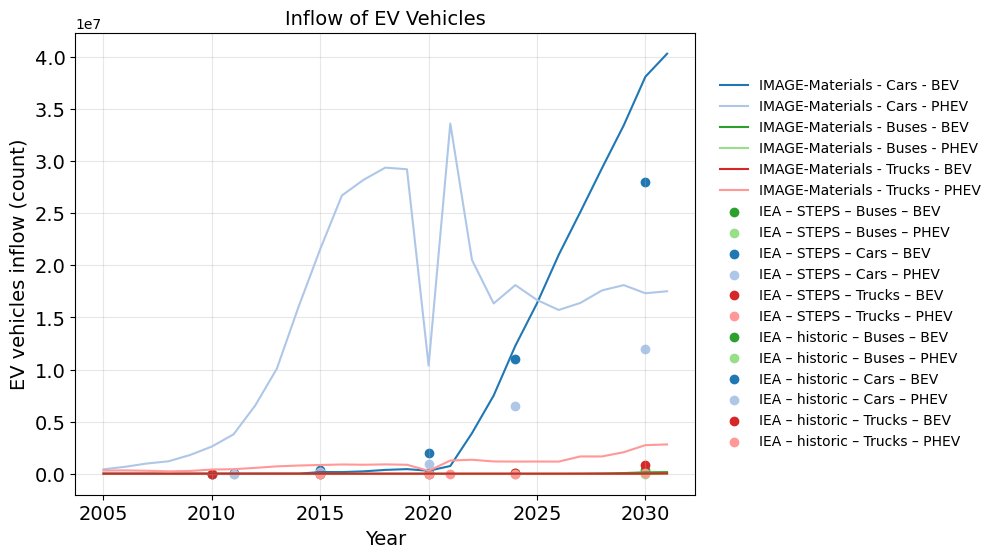

In [33]:
# Plot vehicles inflow #

df = df_ev_vehicles_i.copy()

model = all_output["SSP2_M_CP"]
m1 = model.vehicles["inflow"].to_array().sum(["Region"]).sel(time=slice(2005,2031)) #2005,2031
m1_bev = m1.sel(Type=m1.Type.str.contains("BEV")) #|PHEV
m1_phev = m1.sel(Type=m1.Type.str.contains("PHEV"))
cars_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Cars")).sum("Type")
cars_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Cars")).sum("Type")
buses_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Buses")).sum("Type")
buses_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Buses")).sum("Type")
trucks_bev = m1_bev.sel(Type=m1_bev.Type.str.contains("Trucks")).sum("Type")
trucks_phev = m1_phev.sel(Type=m1_phev.Type.str.contains("Trucks")).sum("Type")

color_dict = {
    ("Cars", "BEV"): "#1f77b4",
    ("Cars", "PHEV"): "#aec7e8",
    ("Buses", "BEV"): "#2ca02c",
    ("Buses", "PHEV"): "#98df8a",
    ("Trucks", "BEV"): "#d62728",
    ("Trucks", "PHEV"): "#ff9896",
}


fig, ax = plt.subplots(figsize=(8,6))

plt.plot(cars_bev.time, cars_bev, label="IMAGE-Materials - Cars - BEV", color=color_dict[("Cars", "BEV")])
plt.plot(cars_phev.time, cars_phev, label="IMAGE-Materials - Cars - PHEV", color=color_dict[("Cars", "PHEV")])
plt.plot(buses_bev.time, buses_bev, label="IMAGE-Materials - Buses - BEV", color=color_dict[("Buses", "BEV")])
plt.plot(buses_phev.time, buses_phev, label="IMAGE-Materials - Buses - PHEV", color=color_dict[("Buses", "PHEV")])
plt.plot(trucks_bev.time, trucks_bev, label="IMAGE-Materials - Trucks - BEV", color=color_dict[("Trucks", "BEV")])
plt.plot(trucks_phev.time, trucks_phev, label="IMAGE-Materials - Trucks - PHEV", color=color_dict[("Trucks", "PHEV")])

for (source, scenario, tech, subtech), g in df.groupby(["source", "scenario", "Technology", "Sub-Technology"]):
    plt.scatter(g.index, g["value"], label=f"{source} – {scenario} – {tech} – {subtech}", color=color_dict[(tech, subtech)], linewidth=1)

# ax.set_ylim(0,200000000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.ylabel(f"EV vehicles inflow (count)", fontsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.grid(alpha=0.3)
plt.title(f"Inflow of EV Vehicles", fontsize=14)

## old vs. new

#### i: battery materials

Text(0.5, 1.0, 'inflow_battery_materials in EV batteries')

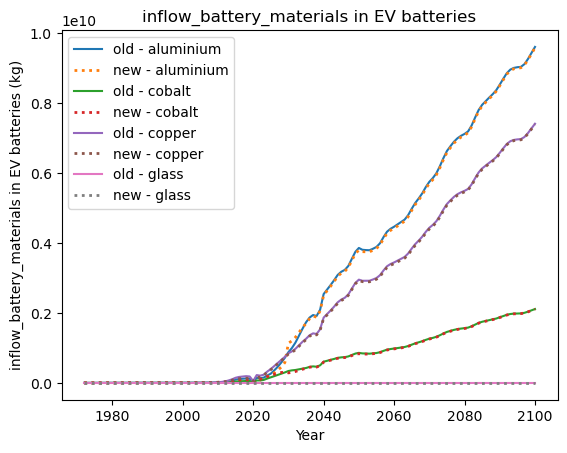

In [91]:
# Plot ev_battery: materials over time
var = "inflow_battery_materials"

model = all_output_old["SSP2_M_CP"]
m1 = model.vehicles[var].sum(["battery", "Region", "Type"]).sel(Time=slice(1972,None))
model = all_output["SSP2_M_CP"]
m2 = model.ev_battery[var].to_array().sum(["BatteryType", "Region", "Type"]).sel(time=slice(1972,None))

for mat in m1.material.values[:4]: #
    plt.plot(m1.Time, m1.sel(material=mat), label="old - " + str(mat))
    plt.plot(m2.time, m2.sel(material=mat), label="new - " + str(mat), linestyle=":", linewidth=2)
    
plt.xlabel("Year")
plt.ylabel(f"{var} in EV batteries (kg)")
plt.legend()
plt.title(f"{var} in EV batteries")

In [ ]:
model.vehicles.keys()